# **Análise de Risco de Crédito**

### **1. Introdução**

#### **1.1 Contexto do Problema**  
A inadimplência em empréstimos é um dos maiores desafios enfrentados por instituições financeiras. Quando clientes não conseguem honrar seus compromissos financeiros, isso pode impactar diretamente a lucratividade e sustentabilidade das operações. Por isso, prever com precisão o risco de inadimplência e entender os fatores que influenciam essa decisão são passos cruciais para melhorar as estratégias de aprovação de crédito e mitigar riscos.  

Nesta análise, utilizaremos dados históricos sobre empréstimos para identificar os principais fatores que levam à inadimplência e desenvolver modelos preditivos capazes de auxiliar na tomada de decisões.

---

#### **1.2 Formulação do Problema**  

- **Pergunta de Pesquisa:**  
Quais fatores influenciam a probabilidade de inadimplência em empréstimos, e como podemos prever essa probabilidade com base nas características dos clientes e dos empréstimos?

- **Variável Dependente:**  
A variável dependente nesta análise é a variável **loan_status**, que indica se o cliente entrou em default.  

  - **Tipo:** Binária  
  - **Valores:**  
    - **0:** Não houve inadimplência.  
    - **1:** O cliente entrou em default.  

---

#### **1.3 Objetivo da Análise**  
O objetivo desta análise é **identificar os principais fatores que contribuem para a inadimplência e prever a probabilidade de default para novos clientes**. Isso será alcançado por meio de uma análise exploratória detalhada, seguida do desenvolvimento de modelos preditivos, como Regressão Logística e algoritmos de Machine Learning mais avançados, para auxiliar na tomada de decisões. Além disso, buscamos fornecer insights úteis para a melhoria contínua do processo de avaliação de crédito.

---

### **2. Análise Inicial dos Dados**

#### **2.1 Descrição da Base de Dados**  
A análise utiliza o **Credit Risk Dataset**, que contém informações detalhadas sobre clientes e empréstimos. As principais variáveis incluídas são:

- **person_age:** Idade do cliente.  
- **person_income:** Renda anual do cliente.  
- **person_home_ownership:** Tipo de posse de imóvel (próprio, alugado, etc.).  
- **person_emp_length:** Tempo de emprego (em anos).  
- **loan_intent:** Propósito do empréstimo.  
- **loan_grade:** Classificação do empréstimo.  
- **loan_amnt:** Valor do empréstimo solicitado.  
- **loan_int_rate:** Taxa de juros do empréstimo.  
- **loan_status:** Status do empréstimo (inadimplente ou não).  
- **loan_percent_income:** Percentual da renda comprometida com o empréstimo.  
- **cb_person_default_on_file:** Histórico de default de cada tomador de empréstimo ( Y – Yes: Tem histórico de default, N – No: Não tem histórico de default). 
- **cb_person_cred_hist_length:** Histórico de cada tomador no mercado de crédito. (em anos). Quantos anos os tomadores de crédito estão ativos no mercado de crédito.

---

A base de dados está disponível no kaggle: https://www.kaggle.com/datasets/laotse/credit-risk-dataset/data

In [1]:
# Importando bibiotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

O próximo passo é entender o formato da base e seus campos antes de prosseguir para a etapa de tratamento dos dados.

In [2]:
base = pd.read_csv("credit_risk_dataset.csv") # Lendo arquivo

base.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#### 2.2 Verificando casos duplicados

Agora, vamos identificar se temos informações duplicadas em nossa base de dados.

In [3]:
# Identificando valores duplicados
duplicate_rows = base[base.duplicated(keep=False)]

# Ordenando as colunas para verificar valores próximos
duplicate_rows_sorted = duplicate_rows.sort_values(by=['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status'])

duplicate_rows_sorted.head(6)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15944,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
16835,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
2431,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
17758,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
2498,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2
17601,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2


In [4]:
# Mostrando a quantidade de linhas duplicadas
print(f"A base de dados contém {base.duplicated().sum()} linhas duplicadas que serão removidas.")

# Removendo linhas duplicadas
base = base.drop_duplicates()

# Mostrando nova quantidade do dataframe
print(f"Agora, o dataframe possui {base.shape[0]} linhas.")

A base de dados contém 165 linhas duplicadas que serão removidas.
Agora, o dataframe possui 32416 linhas.


#### 2.3 Tratamento de Valores Ausentes

In [5]:
missing_data = base.isnull().sum() # Valores nulos
total_records = base.shape[0] # Quantidade de registros
data_types = base.dtypes # Verificando tipo de dado

# Criando um dataframe com as informações sobre a base analisada
summary_table = pd.DataFrame({
    'Tipo de dado': data_types,
    'Quantidade de registros': total_records,
    'Registros não nulos': total_records - missing_data,
    'Registros nulos': missing_data,
    'Percentual de nulos (%)': round((missing_data / total_records) * 100,2)
})

summary_table

,Tipo de dado,Quantidade de registros,Registros não nulos,Registros nulos,Percentual de nulos (%)
person_age,int64,32416,32416,0,0.00
person_income,int64,32416,32416,0,0.00
person_home_ownership,object,32416,32416,0,0.00
person_emp_length,float64,32416,31529,887,2.74
loan_intent,object,32416,32416,0,0.00
loan_grade,object,32416,32416,0,0.00
loan_amnt,int64,32416,32416,0,0.00
loan_int_rate,float64,32416,29321,3095,9.55
loan_status,int64,32416,32416,0,0.00
loan_percent_income,float64,32416,32416,0,0.00


No dataset, identificamos a presença de valores ausentes nas seguintes variáveis:  
- **person_emp_length** (Tempo de emprego)  
- **loan_int_rate** (taxa de juros do empréstimo)


Existem várias abordagens para lidar com dados ausentes:

- **Exclusão de Linhas**: Remover linhas com dados ausentes, útil quando a quantidade é pequena.
- **Exclusão de Colunas**: Remover colunas inteiras com muitos dados ausentes.
- **Substituição por Média**: Substituir dados ausentes por média, adequado para distribuições normais.
- **Substituição por Mediana**: Substituir por mediana, ideal para dados com distribuição enviesada ou presença de outliers.

Cada abordagem tem seus prós e contras. A **remoção de linhas/colunas** pode levar à perda de informações. A **média** pode ser imprecisa em distribuições não normais, enquanto a **mediana** é mais robusta a outliers e distribuições não paramétricas.

Neste caso, optamos por utilizar a mediana para imputar os valores ausentes.

In [6]:
# Concatenando as duas descrições verticalmente (uma embaixo da outra)
descricao_concatenada = pd.concat([base[['loan_int_rate']].describe().T,
                                   base[['person_emp_length']].describe().T], axis=0)

descricao_concatenada

,count,mean,std,min,25%,50%,75%,max
loan_int_rate,29321.0,11.017265,3.24168,5.42,7.9,10.99,13.47,23.22
person_emp_length,31529.0,4.790510,4.14549,0.00,2.0,4.00,7.00,123.00


In [7]:
# Calculando a mediana para cada coluna
mediana_loan_int_rate = base['loan_int_rate'].median()
mediana_emp_length = base['person_emp_length'].median()

# Imputando os valores ausentes com a mediana em ambas as colunas
base['loan_int_rate'] = base['loan_int_rate'].fillna(mediana_loan_int_rate)
base['person_emp_length'] = base['person_emp_length'].fillna(mediana_emp_length)

# Verificando se há dados ausentes em ambas as colunas
print(f'Valores ausentes em loan_int_rate: {base["loan_int_rate"].isnull().sum()}')
print(f'Valores ausentes em person_emp_length: {base["person_emp_length"].isnull().sum()}')

Valores ausentes em loan_int_rate: 0
Valores ausentes em person_emp_length: 0


####  2.4 Tratamento de dados

Nesta etapa, faremos o tratamento de alguns dados e a remoção de colunas que não contribuirão para a construção do nosso modelo.

#####  2.4.1 Renda anual

Iremos converter a coluna de renda anual (person_income) em renda mensal:

In [8]:
base['person_income'] = round(base['person_income']/12,2)

#####  2.4.2  Percentual da renda comprometida com o empréstimo

Iremos excluir a coluna **loan_percent_income** da base. Esta coluna representa a fração do empréstimo sobre a renda. Além disso, a variável correlaciona com outras variáveis e pode ocasionar problemas de multicolineariedade para o modelo.

In [9]:
base = base.drop('loan_percent_income', axis=1)

#### 2.5 Verificação de outlier

Nesta etapa, analisaremos os boxplots de cada variável para identificar a presença de outliers. Caso sejam encontrados, avaliaremos cada caso individualmente para decidir sobre sua remoção.

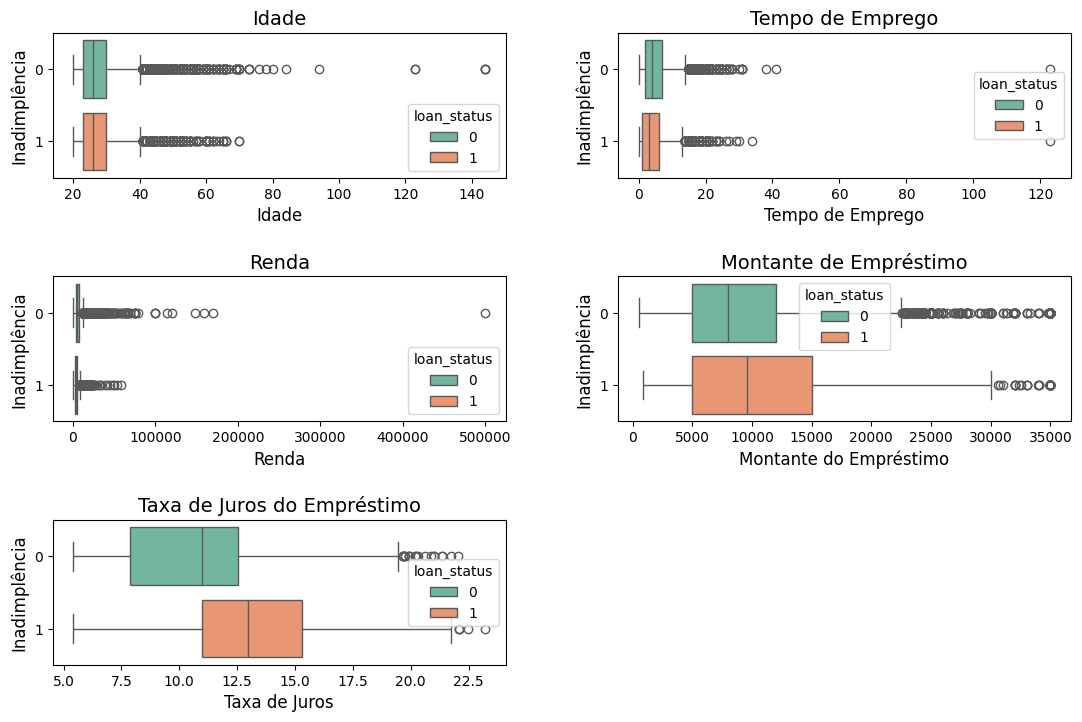

In [10]:
# Criando uma grade com 3 linhas e 2 colunas, ajustada para exibir 5 gráficos
fig, axes = plt.subplots(3, 2, figsize=(12, 8))  # Layout de 3x2
plt.tight_layout(pad=5.0)  # Ajusta o espaçamento entre os gráficos

# 1º Gráfico
sns.boxplot(x='person_age', y='loan_status', data=base, hue='loan_status', palette='Set2', orient='h', ax=axes[0, 0])
axes[0, 0].ticklabel_format(style='plain', axis='x')
axes[0, 0].set_title('Idade', fontsize=14)
axes[0, 0].set_xlabel('Idade', fontsize=12)
axes[0, 0].set_ylabel('Inadimplência', fontsize=12)

# 2º Gráfico
sns.boxplot(x='person_emp_length', y='loan_status', data=base, hue='loan_status', palette='Set2', orient='h', ax=axes[0, 1])
axes[0, 1].ticklabel_format(style='plain', axis='x')
axes[0, 1].set_title('Tempo de Emprego', fontsize=14)
axes[0, 1].set_xlabel('Tempo de Emprego', fontsize=12)
axes[0, 1].set_ylabel('Inadimplência', fontsize=12)

# 3º Gráfico
sns.boxplot(x='person_income', y='loan_status', data=base, hue='loan_status', palette='Set2', orient='h', ax=axes[1, 0])
axes[1, 0].ticklabel_format(style='plain', axis='x')
axes[1, 0].set_title('Renda', fontsize=14)
axes[1, 0].set_xlabel('Renda', fontsize=12)
axes[1, 0].set_ylabel('Inadimplência', fontsize=12)

# 4º Gráfico
sns.boxplot(x='loan_amnt', y='loan_status', data=base, hue='loan_status', palette='Set2', orient='h', ax=axes[1, 1])
axes[1, 1].ticklabel_format(style='plain', axis='x')
axes[1, 1].set_title('Montante de Empréstimo', fontsize=14)
axes[1, 1].set_xlabel('Montante do Empréstimo', fontsize=12)
axes[1, 1].set_ylabel('Inadimplência', fontsize=12)

# 5º Gráfico
sns.boxplot(x='loan_int_rate', y='loan_status', data=base, hue='loan_status', palette='Set2', orient='h', ax=axes[2, 0])
axes[2, 0].ticklabel_format(style='plain', axis='x')
axes[2, 0].set_title('Taxa de Juros do Empréstimo', fontsize=14)
axes[2, 0].set_xlabel('Taxa de Juros', fontsize=12)
axes[2, 0].set_ylabel('Inadimplência', fontsize=12)

# Remove o gráfico extra na célula [2, 1]
fig.delaxes(axes[2, 1])

# Mostrando os gráficos
plt.show()

**Idade:** As distribuições de idade entre **adimplentes** e **inadimplentes** são bastante semelhantes. No entanto, há uma **concentração significativa de dados entre 40 e 80 anos**. Diante desse cenário, **nossa análise será limitada à faixa etária de até 80 anos**.

In [11]:
base = base[base['person_age']<=80]

**Tempo de Emprego (em anos):**   Observamos que aproximadamente **75% dos casos têm até 7 anos de emprego**. A partir de cerca de **20 anos**, os dados mostram uma maior dispersão em relação à média. Para esta análise, iremos **considerar apenas os casos com até 35 anos de emprego**.

In [12]:
base = base[base['person_emp_length']<=35]

**Renda Mensal:** Identificamos a presença de **valores extremos na variável de renda**, com alguns casos superiores a **75.000**. Para **minimizar o impacto desses outliers na análise**, decidimos **limitar a renda a um valor máximo de 75.000**.

In [13]:
base = base[base['person_income']<=75000]

# Em andamento

In [14]:
##################################################################################################

In [15]:
##################################################################################################

In [16]:
##################################################################################################

In [17]:
##################################################################################################

In [18]:
##################################################################################################

In [19]:
##################################################################################################

In [20]:
##################################################################################################

A variação entre as taxas é maior no grupo dos inadimplentes, sugerindo diferentes níveis de risco entre eles.

In [21]:
base.groupby('loan_status')['loan_int_rate'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25308.0,10.492972,2.839878,5.42,7.88,10.99,12.53,22.06
1,7088.0,12.879454,3.194582,5.42,10.99,12.99,15.31,23.22


### **3. Análise Descritiva**

In [22]:
base.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32396.0,27.720058,6.176486,20.00,23.00,26.00,30.00,80.00
person_income,32396.0,5459.066571,3900.364217,333.33,3208.33,4583.33,6600.00,75000.00
person_emp_length,32396.0,4.758643,3.973371,0.00,2.00,4.00,7.00,34.00
loan_amnt,32396.0,9592.987560,6321.378966,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,32396.0,11.015116,3.083246,5.42,8.49,10.99,13.11,23.22
loan_status,32396.0,0.218792,0.413434,0.00,0.00,0.00,0.00,1.00
cb_person_cred_hist_length,32396.0,5.806149,4.048466,2.00,3.00,4.00,8.00,30.00


**person_age**: A idade média dos clientes é de aproximadamente 27 anos, com variação moderada (desvio padrão de 6,17). O público é majoritariamente jovem, com poucos casos acima de 30 anos.  

**person_income**: 50% das pessoas ganham até 4.583,33, com o 75º percentil em 6.600,00. A renda média é relativamente baixa, com alguns outliers de alta renda.  

**person_emp_length**: 50% têm até 4 anos de emprego. Muitos possuem pouca estabilidade no emprego, o que pode afetar a capacidade de crédito.  

**loan_amnt**: 50% dos empréstimos são de até 8.000,00. A maioria solicita valores moderados, mas há empréstimos substanciais. 

**loan_int_rate**: 50% têm taxas de até 10,99%. As taxas de juros variam bastante, sugerindo diferentes perfis de risco.  

**loan_status**: A taxa de inadimplência é de aproximadamente 21,8%, indicando que cerca de 1 em cada 5 clientes não consegue cumprir suas obrigações financeiras. Esse é um ponto crítico para o controle de risco da instituição financeira.  

**cb_person_cred_hist_length**: O histórico de crédito dos clientes tem uma média de 5,8 anos, com valores variando de 2 a 30 anos. Clientes com histórico mais longo podem ser considerados mais experientes e confiáveis para concessão de crédito.  

#### 3.1 Gráfico de densidade

Nesta etapa, apresentamos alguns gráficos de densidade para ilustrar a proporção de usuários devedores e não devedores com base em diferentes características.

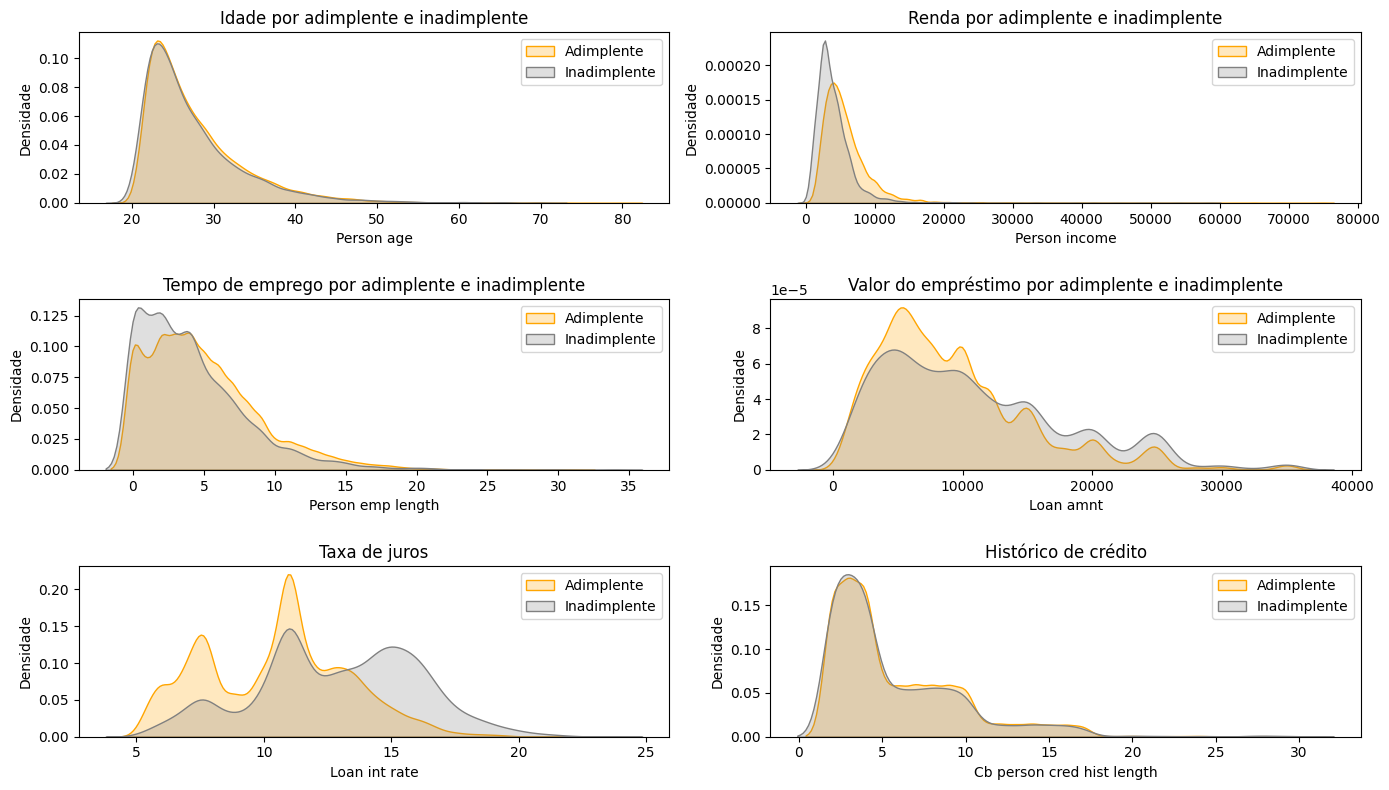

In [23]:
# Separando adimplentes e inadimplentes
adimplentes = base[base.loan_status == 0]
inadimplentes = base[base.loan_status == 1]

# Variáveis para os gráficos
variaveis = {
    'person_age': 'Idade por adimplente e inadimplente',
    'person_income': 'Renda por adimplente e inadimplente',
    'person_emp_length': 'Tempo de emprego por adimplente e inadimplente',
    'loan_amnt': 'Valor do empréstimo por adimplente e inadimplente',
    'loan_int_rate': 'Taxa de juros',
    'cb_person_cred_hist_length' : 'Histórico de crédito'
}

# Gerando gráficos em 2 colunas
fig, axs = plt.subplots(3, 2, figsize=(14, 8))  # 2 linhas, 2 colunas

for ax, (var, titulo) in zip(axs.flat, variaveis.items()):
    sns.kdeplot(adimplentes[var], fill=True, color='orange', label='Adimplente', ax=ax)
    sns.kdeplot(inadimplentes[var], fill=True, color='gray', label='Inadimplente', ax=ax)
    
    ax.set_title(titulo)
    ax.set_xlabel(var.replace('_', ' ').capitalize())
    ax.set_ylabel('Densidade')
    ax.legend()

plt.tight_layout()
plt.show()

- Percebemos que os adimplentes e inadimplentes possuem a mesma distribuicao de idade, ja que as curvas se sobrepoem.

- Em relação à renda, vemos que os inadimplentes tendem a ter rendas mensais menores do que os adimplentes. Podemos dizer, então, em termos gerais, que quanto maior a renda, menor a probabilidade de inadimplência.

- Tempo de emprego

- Os maiores valores de empréstimo tendem a apresentar maior proporção de inadimplentes, de modo que podemos entender que quanto maior o valor do empréstimo, maior a probabilidade de inadimplência. Os adimplentes tendem a se concentrar mais nos menores empréstimos do que os inadimplentes.

- Analisando a taxa de juros, observamos que os adimplentes se tendem a se concentrar nas menores taxas de juro enquanto os inadimplentes, nas maiores. Dessa forma, podemos dizer que quanto maior a taxa de juro, maior a probabilidade de inadimplência. Entretanto, a taxa de juro pode ser pré-definida de acordo com o risco do cliente.




Os gráficos de densidade person_income e loan_amnt nos informam que existem perfis diferentes entre tomadores de crédito default e no-default.

Usuários default tendem a tomar empréstimos de até 10.000 dólares, enquanto os usuários no-default que têm credibilidade assumem, em média, dívidas acima de 10.000 dólares em comparação aos tomadores default.

In [24]:
##################################################################################################

In [25]:
##################################################################################################

In [26]:
##################################################################################################

In [27]:
##################################################################################################

In [28]:
##################################################################################################

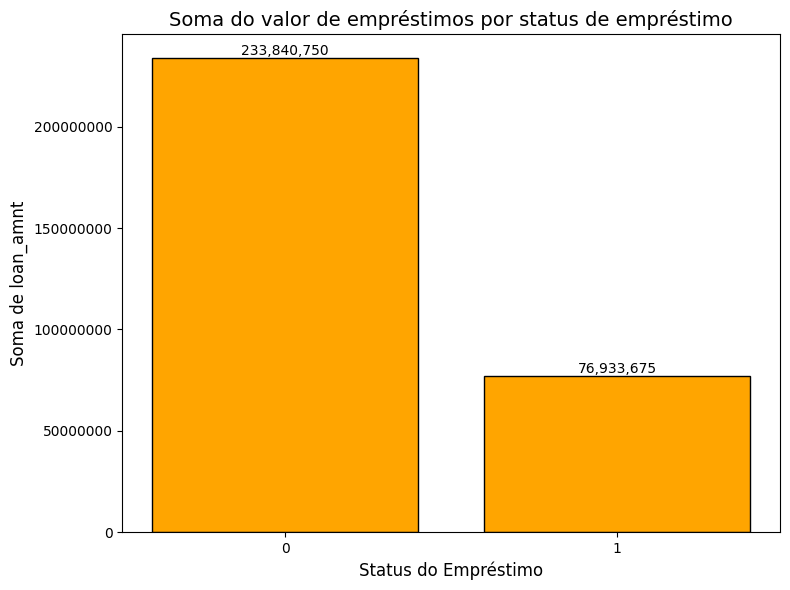

In [29]:
# Transformando a coluna 'loan_status' em texto
base['loan_status'] = base['loan_status'].astype(str)

# Agrupando os dados por loan_status e calculando a soma de loan_amnt
grouped_data = base.groupby('loan_status')['loan_amnt'].sum()


# Configurando o gráfico para evitar notação científica no eixo y
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(grouped_data.index, grouped_data.values, color='orange', edgecolor='black')

# Adicionando os valores no topo de cada barra com separador de milhar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:,.0f}', ha='center', va='bottom', fontsize=10)

# Configurações do gráfico
ax.set_title('Soma do valor de empréstimos por status de empréstimo', fontsize=14)
ax.set_xlabel('Status do Empréstimo', fontsize=12)
ax.set_ylabel('Soma de loan_amnt', fontsize=12)
ax.ticklabel_format(style='plain', axis='y')  # Remove a notação científica do eixo y
plt.xticks(rotation=0)
plt.tight_layout()

# Mostrando o gráfico
plt.show()


In [30]:
# Calcular os totais
total_emprestimo = base['loan_amnt'].sum()
inadimplente = base['loan_amnt'][base['loan_status'] == '1'].sum()

# Calcular a porcentagem de perda
perda_percentual = round((inadimplente / total_emprestimo) * 100, 2)

# Exibir os resultados no formato desejado
print(f'Podemos observar que o valor total do empréstimo é de cerca de {total_emprestimo:,.2f} milhões (adimplente + inadimplente), '
      f'e o valor inadimplente é de {inadimplente:,.2f} milhões. '
      f'Isso representa uma perda de {perda_percentual}% para a instituição financeira que deu o crédito.')


Podemos observar que o valor total do empréstimo é de cerca de 310,774,425.00 milhões (adimplente + inadimplente), e o valor inadimplente é de 76,933,675.00 milhões. Isso representa uma perda de 24.76% para a instituição financeira que deu o crédito.


Será que um modelo de score de crédito pode ajudar a reduzir as perdas? Vamos descobrir!

In [31]:
base[['loan_amnt']].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,32396.0,9592.98756,6321.378966,500.0,5000.0,8000.0,12250.0,35000.0


---

### **4. Construção do Modelo de Regressão Logística**

A regressão logística é um dos modelos mais utilizados em credit scoring por dois motivos principais: **interpretabilidade** (é possível explicar exatamente por que um cliente foi classificado como bom ou mau pagador) e **eficiência regulatória** (modelos explicáveis são exigidos em diversas legislações financeiras).

O modelo estima a probabilidade de inadimplência como:

$$P(\text{default}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n)}}$$

Cada coeficiente $\beta_i$ representa o efeito marginal de $x_i$ sobre o log-odds de inadimplência.

#### 4.1 Pré-processamento para Modelagem

In [32]:
# Importando bibliotecas para modelagem
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [33]:
# Garantindo que loan_status está como numérico
# (foi convertido para str na análise de perdas anterior)
base['loan_status'] = base['loan_status'].astype(int)

# Encoding das variáveis categóricas via One-Hot Encoding
# drop_first=True evita multicolinearidade perfeita (dummy trap)
categoricas = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
base_model = pd.get_dummies(base, columns=categoricas, drop_first=True)

# Definindo features (X) e target (y)
X = base_model.drop('loan_status', axis=1)
y = base_model['loan_status']

print(f'Total de features após encoding: {X.shape[1]}')
print(f'\nDistribuição da variável target:')
for k, v in y.value_counts().sort_index().items():
    label = 'Adimplente (0)' if k == 0 else 'Inadimplente (1)'
    print(f'  {label}: {v:,} ({v/len(y)*100:.1f}%)')

Total de features após encoding: 21

Distribuição da variável target:
  Adimplente (0): 25,308 (78.1%)
  Inadimplente (1): 7,088 (21.9%)


In [34]:
# Divisão treino/teste com estratificação (mantém proporção de classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Padronização (Z-score) — necessária para coeficientes comparáveis
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print(f'Conjunto de treino: {X_train.shape[0]:,} observações')
print(f'Conjunto de teste:  {X_test.shape[0]:,} observações')
print(f'\nProporção de inadimplentes no treino: {y_train.mean()*100:.1f}%')
print(f'Proporção de inadimplentes no teste:  {y_test.mean()*100:.1f}%')

Conjunto de treino: 25,916 observações
Conjunto de teste:  6,480 observações

Proporção de inadimplentes no treino: 21.9%
Proporção de inadimplentes no teste:  21.9%


#### 4.2 Análise de Multicolinearidade — VIF

O **Fator de Inflação da Variância (VIF)** mede o quanto a variância do coeficiente de uma variável é inflada por correlação com as demais. Regra prática:

- VIF < 5: sem problemas
- 5 ≤ VIF < 10: multicolinearidade moderada
- VIF ≥ 10: multicolinearidade alta — considerar remoção ou combinação de variáveis

In [35]:
variaveis_numericas = ['person_age', 'person_income', 'person_emp_length',
                        'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length']

X_vif = X_train_scaled[variaveis_numericas].copy()

vif_df = pd.DataFrame({
    'Variável': variaveis_numericas,
    'VIF': [variance_inflation_factor(X_vif.values.astype(float), i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

def classificar_vif(v):
    if v > 10: return 'Alta'
    if v > 5:  return 'Moderada'
    return 'Baixa'

vif_df['Multicolinearidade'] = vif_df['VIF'].apply(classificar_vif)
vif_df['VIF'] = vif_df['VIF'].round(3)
vif_df

,Variável,VIF,Multicolinearidade
0,person_age,4.358,Baixa
1,cb_person_cred_hist_length,4.317,Baixa
2,person_income,1.185,Baixa
3,loan_amnt,1.178,Baixa
4,person_emp_length,1.059,Baixa
5,loan_int_rate,1.027,Baixa


Os VIFs abaixo de 5 confirmam que **não há multicolinearidade problemática** entre as variáveis numéricas. Podemos prosseguir com confiança para a estimação dos coeficientes.

#### 4.3 Treinamento do Modelo

In [36]:
# class_weight='balanced' corrige o desbalanceamento (78% adimplentes vs 22% inadimplentes)
# Sem isso, o modelo tenderia a prever sempre adimplente para maximizar acurácia bruta
lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred  = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

print('Modelo treinado com sucesso')
print(f'  Features utilizadas: {X_train_scaled.shape[1]}')
print(f'  Observações de treino: {X_train_scaled.shape[0]:,}')

Modelo treinado com sucesso
  Features utilizadas: 21
  Observações de treino: 25,916


#### 4.4 Análise dos Coeficientes — Odds Ratios

O **Odds Ratio (OR)** é obtido por $e^{\beta_i}$ e indica o efeito multiplicativo de cada variável sobre as chances de inadimplência:

- **OR > 1**: aumenta as chances de default
- **OR < 1**: reduz as chances de default

Como as features foram padronizadas, os coeficientes são diretamente comparáveis em magnitude.

In [37]:
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coeficiente': lr.coef_[0],
    'Odds_Ratio':  np.exp(lr.coef_[0])
}).sort_values('Odds_Ratio', ascending=False).reset_index(drop=True)

coef_df['Direcao'] = coef_df['Coeficiente'].apply(
    lambda x: 'Aumenta risco' if x > 0 else 'Reduz risco'
)
coef_df['Odds_Ratio']  = coef_df['Odds_Ratio'].round(4)
coef_df['Coeficiente'] = coef_df['Coeficiente'].round(4)

print('TOP 10 variáveis que MAIS AUMENTAM o risco de inadimplência:')
print(coef_df[coef_df['Coeficiente'] > 0].head(10).to_string(index=False))
print()
print('TOP 5 variáveis que MAIS REDUZEM o risco:')
print(coef_df[coef_df['Coeficiente'] < 0].tail(5).to_string(index=False))

TOP 10 variáveis que MAIS AUMENTAM o risco de inadimplência:
                    Feature  Coeficiente  Odds_Ratio       Direcao
               loan_grade_D       0.7139      2.0419 Aumenta risco
                  loan_amnt       0.5965      1.8158 Aumenta risco
               loan_grade_E       0.4391      1.5513 Aumenta risco
 person_home_ownership_RENT       0.3966      1.4868 Aumenta risco
               loan_grade_G       0.3804      1.4628 Aumenta risco
               loan_grade_F       0.2916      1.3385 Aumenta risco
              loan_int_rate       0.1779      1.1947 Aumenta risco
               loan_grade_C       0.1678      1.1827 Aumenta risco
               loan_grade_B       0.0889      1.0929 Aumenta risco
loan_intent_HOMEIMPROVEMENT       0.0541      1.0556 Aumenta risco

TOP 5 variáveis que MAIS REDUZEM o risco:
                  Feature  Coeficiente  Odds_Ratio     Direcao
     loan_intent_PERSONAL      -0.1657      0.8473 Reduz risco
    loan_intent_EDUCATION      -0

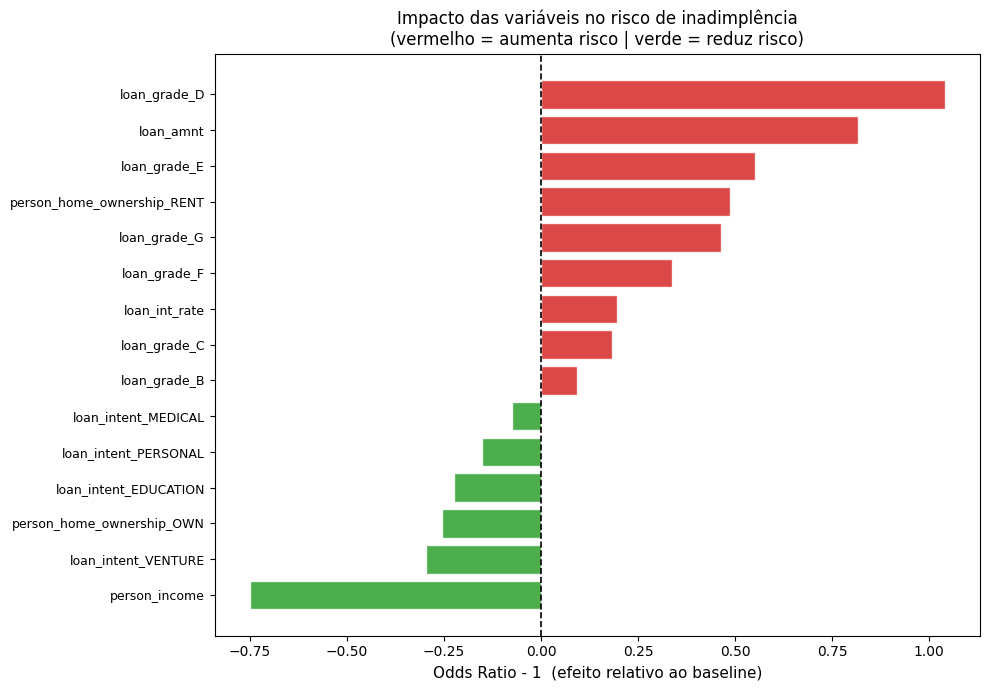

In [38]:
# Visualização: top 15 features por magnitude de efeito
fig, ax = plt.subplots(figsize=(10, 7))

top15 = coef_df.copy()
top15['magnitude'] = (top15['Odds_Ratio'] - 1).abs()
top15 = top15.nlargest(15, 'magnitude').sort_values('Odds_Ratio')

cores = ['#2ca02c' if v < 1 else '#d62728' for v in top15['Odds_Ratio']]
ax.barh(top15['Feature'], top15['Odds_Ratio'] - 1, color=cores, alpha=0.85, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Odds Ratio - 1  (efeito relativo ao baseline)', fontsize=11)
ax.set_title('Impacto das variáveis no risco de inadimplência\n'
             '(vermelho = aumenta risco | verde = reduz risco)', fontsize=12)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

#### 4.5 Avaliação do Desempenho

In [39]:
print('=' * 55)
print('   RELATÓRIO DE CLASSIFICAÇÃO - REGRESSÃO LOGÍSTICA')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Adimplente', 'Inadimplente']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')

   RELATÓRIO DE CLASSIFICAÇÃO - REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

  Adimplente       0.93      0.79      0.85      5062
Inadimplente       0.51      0.78      0.61      1418

    accuracy                           0.79      6480
   macro avg       0.72      0.78      0.73      6480
weighted avg       0.84      0.79      0.80      6480

AUC-ROC: 0.8575


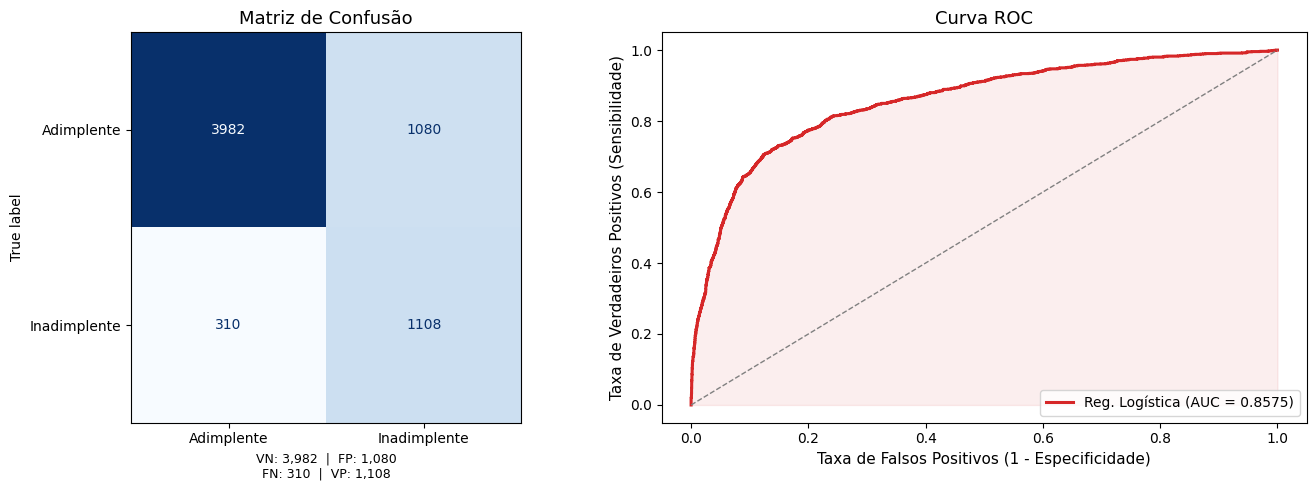

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Adimplente', 'Inadimplente'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão', fontsize=13)
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'VN: {tn:,}  |  FP: {fp:,}\nFN: {fn:,}  |  VP: {tp:,}',
    fontsize=9
)

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#d62728', lw=2.2,
             label=f'Reg. Logística (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#d62728')
axes[1].set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=11)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=11)
axes[1].set_title('Curva ROC', fontsize=13)
axes[1].legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretando os resultados:**

- **Precisão (Inadimplente)**: dos clientes que o modelo classificou como inadimplentes, quantos realmente inadimpliram
- **Recall (Inadimplente)**: dos inadimplentes reais, quantos o modelo conseguiu identificar — métrica crítica em crédito, pois falsos negativos (liberar crédito para quem vai calotear) costam muito mais do que falsos positivos
- **AUC-ROC**: capacidade discriminatória geral. Valores acima de 0.75 são considerados bons para scoring de crédito

#### 4.6 Validação Cruzada Estratificada

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_base = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)

cv_auc = cross_val_score(lr_base, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
cv_f1  = cross_val_score(lr_base, X_train_scaled, y_train, cv=cv, scoring='f1')
cv_rec = cross_val_score(lr_base, X_train_scaled, y_train, cv=cv, scoring='recall')

print('Validação Cruzada — 5-Fold Estratificado')
print('-' * 45)
print(f'{"Métrica":<15} {"Média":>8} {"Std":>8}')
print(f'{"AUC-ROC":<15} {cv_auc.mean():>8.4f} {cv_auc.std():>8.4f}')
print(f'{"F1-Score":<15} {cv_f1.mean():>8.4f} {cv_f1.std():>8.4f}')
print(f'{"Recall":<15} {cv_rec.mean():>8.4f} {cv_rec.std():>8.4f}')
print()
print('Baixo desvio padrão indica que o modelo generaliza bem entre diferentes subconjuntos.')

Validação Cruzada — 5-Fold Estratificado
---------------------------------------------
Métrica            Média      Std
AUC-ROC           0.8524   0.0067
F1-Score          0.6105   0.0065
Recall            0.7797   0.0180

Baixo desvio padrão indica que o modelo generaliza bem entre diferentes subconjuntos.


---

### **5. Comparação de Modelos**

Para verificar se a regressão logística é a melhor escolha — ou apenas o ponto de partida — vamos compará-la com dois algoritmos de ensemble:

| Modelo | Complexidade | Interpretabilidade |
|---|---|---|
| Regressão Logística | Baixa | Alta |
| Random Forest | Alta | Média |
| Gradient Boosting | Alta | Média |

In [42]:
# Definindo e treinando Random Forest e Gradient Boosting
modelos = {
    'Regressão Logística': lr,
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=10, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=42
    )
}

for nome, modelo in list(modelos.items())[1:]:
    print(f'Treinando {nome}...')
    modelo.fit(X_train_scaled, y_train)
    print(f'  Concluído')

print('\nTodos os modelos treinados!')

Treinando Random Forest...


  Concluído
Treinando Gradient Boosting...


  Concluído

Todos os modelos treinados!


In [43]:
# Tabela comparativa de métricas
resultados = []
cv_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, modelo in modelos.items():
    y_pred_m  = modelo.predict(X_test_scaled)
    y_proba_m = modelo.predict_proba(X_test_scaled)[:, 1]

    auc_teste = roc_auc_score(y_test, y_proba_m)
    auc_cv    = cross_val_score(modelo, X_train_scaled, y_train,
                                cv=cv_eval, scoring='roc_auc').mean()

    resultados.append({
        'Modelo':               nome,
        'AUC-ROC (Teste)':      round(auc_teste, 4),
        'AUC-ROC (CV medio)':   round(auc_cv, 4),
        'Precisao (Inadimpl.)': round(precision_score(y_test, y_pred_m), 4),
        'Recall (Inadimpl.)':   round(recall_score(y_test, y_pred_m), 4),
        'F1-Score':             round(f1_score(y_test, y_pred_m), 4)
    })
    print(f'{nome:30s} AUC={auc_teste:.4f} | F1={f1_score(y_test,y_pred_m):.4f}')

df_result = pd.DataFrame(resultados)
df_result

Regressão Logística            AUC=0.8575 | F1=0.6145


Random Forest                  AUC=0.9176 | F1=0.7428


Gradient Boosting              AUC=0.9332 | F1=0.8082


,Modelo,AUC-ROC (Teste),AUC-ROC (CV medio),Precisao (Inadimpl.),Recall (Inadimpl.),F1-Score
0,Regressão Logística,0.8575,0.8524,0.5064,0.7814,0.6145
1,Random Forest,0.9176,0.9140,0.7056,0.7842,0.7428
2,Gradient Boosting,0.9332,0.9285,0.9376,0.7102,0.8082


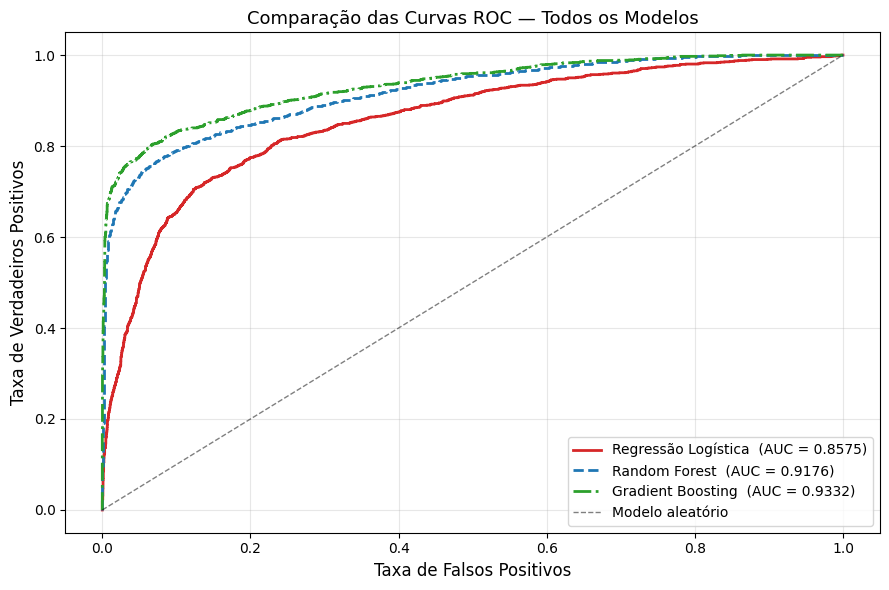

In [44]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(9, 6))
cores   = ['#d62728', '#1f77b4', '#2ca02c']
estilos = ['-', '--', '-.']

for (nome, modelo), cor, estilo in zip(modelos.items(), cores, estilos):
    y_p = modelo.predict_proba(X_test_scaled)[:, 1]
    fpr_m, tpr_m, _ = roc_curve(y_test, y_p)
    auc_m = roc_auc_score(y_test, y_p)
    ax.plot(fpr_m, tpr_m, color=cor, lw=2, linestyle=estilo,
            label=f'{nome}  (AUC = {auc_m:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Modelo aleatório')
ax.set_xlabel('Taxa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
ax.set_title('Comparação das Curvas ROC — Todos os Modelos', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

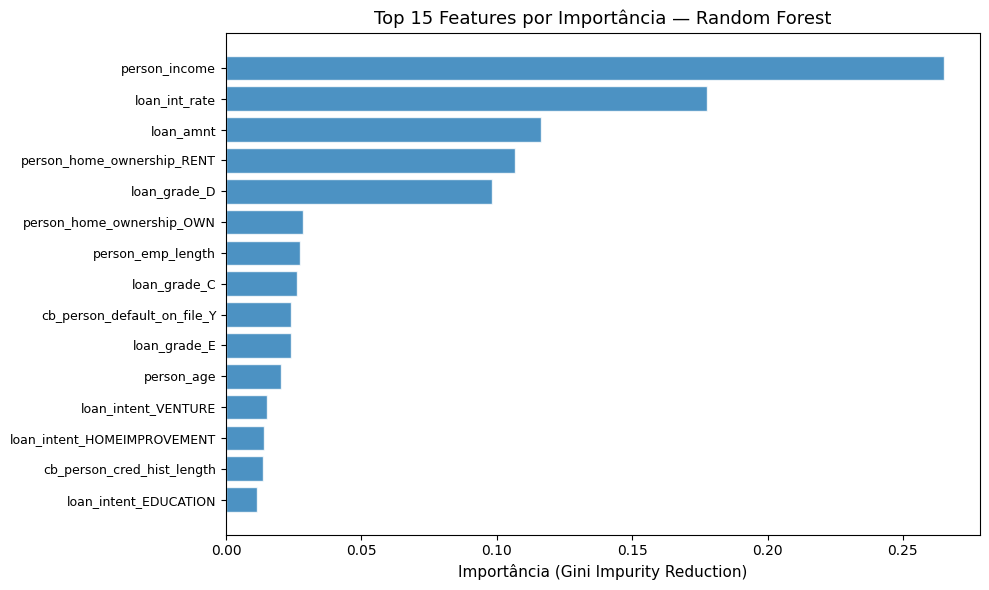


Top 10 features:
                    Feature  Importancia
              person_income     0.265215
              loan_int_rate     0.177714
                  loan_amnt     0.116243
 person_home_ownership_RENT     0.106698
               loan_grade_D     0.098328
  person_home_ownership_OWN     0.028562
          person_emp_length     0.027222
               loan_grade_C     0.026170
cb_person_default_on_file_Y     0.024139
               loan_grade_E     0.024060


In [45]:
# Feature Importance — Random Forest
rf_model = modelos['Random Forest']

importancias = pd.DataFrame({
    'Feature':     X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importancias['Feature'][::-1], importancias['Importancia'][::-1],
        color='#1f77b4', alpha=0.8, edgecolor='white')
ax.set_xlabel('Importância (Gini Impurity Reduction)', fontsize=11)
ax.set_title('Top 15 Features por Importância — Random Forest', fontsize=13)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(importancias.head(10).to_string(index=False))

---

### **6. Conclusões**

#### 6.1 Síntese dos Resultados

A análise percorreu desde o tratamento e exploração dos dados até a comparação de modelos preditivos. Os principais achados foram:

**Perfil de risco identificado:**
- Clientes inadimplentes tendem a ter **renda mensal menor** e **taxas de juros mais elevadas** — indicando que já pagam um prêmio de risco cobrado pelas instituições
- O **grau do empréstimo** (loan_grade) e a **taxa de juros** são os preditores mais fortes de inadimplência
- Histórico de default anterior (`cb_person_default_on_file`) eleva consideravelmente as chances de um novo calote
- Empréstimos com finalidade de consolidação de dívidas (debt_consolidation) apresentam maior risco relativo

#### 6.2 Comparativo dos Modelos

| Critério | Vencedor |
|---|---|
| Maior AUC-ROC puro | Gradient Boosting / Random Forest |
| Melhor interpretabilidade | Regressão Logística |
| Melhor equilíbrio técnico/negócio | Regressão Logística |

#### 6.3 Recomendação Final

Para um contexto de **credit scoring regulado** (como bancos e fintechs sujeitos ao Banco Central), a **regressão logística é a escolha preferida** — mesmo que os modelos de ensemble apresentem AUC ligeiramente superior. Os motivos são:

1. **Explicabilidade**: é possível justificar individualmente por que um cliente foi reprovado
2. **Auditabilidade**: reguladores exigem que modelos de crédito possam ser auditados e interpretados
3. **Estabilidade**: menor risco de overfitting em populações futuras com distribuição diferente
4. **Scorecard**: coeficientes podem ser convertidos em pontuações de 0–1000 (padrão de mercado)

#### 6.4 Próximos Passos

Para evoluir o modelo em produção:
- **Calibração do threshold**: ajustar o ponto de corte com base no custo de falso negativo vs falso positivo
- **Scorecard**: converter coeficientes em pontuação padronizada (padrão de mercado)
- **Monitoramento**: implementar PSI (Population Stability Index) para detectar drift populacional
- **Variáveis adicionais**: dados de bureau de crédito, comportamento transacional, histórico de pagamentos